# Graph Convolutional Network to Overcome Navigation Challenges

By: Apurvata Kumar

Updated: March 2026

In [116]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import networkx as nx
import matplotlib.pyplot as plt
import torch
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import torch.nn.functional as nf
from torch.nn import MSELoss
import heapq

Change below file paths as needed.

In [117]:
# Import customized datasets
simple_file = '/content/custom_data_simple.csv'
# For both medium and complex datasets
complex_file = '/content/custom_data_complex.csv'

Using three types of datasets for three phases. I am commenting out the others when one dataset is in use.

Use country code/latitude/longitude keywords for the medium and complex dataset.

In [118]:
# Create dataset for "simple" phase
df = pd.read_csv(simple_file).iloc[2:53]

# Convert longitude and latitude to integer for simple phase
df['usa_state_longitude'] = df['usa_state_longitude'].fillna(0).astype(int)
df['usa_state_latitude'] = df['usa_state_latitude'].fillna(0).astype(int)

# Select 5 rows at random for 10 different sets (8 for training and 2 for testing)
df_simple1 = df.sample(n=5)
df_simple2 = df.sample(n=5)
df_simple3 = df.sample(n=5)
df_simple4 = df.sample(n=5)
df_simple5 = df.sample(n=5)
df_simple6 = df.sample(n=5)
df_simple7 = df.sample(n=5)
df_simple8 = df.sample(n=5)
# For testing
df_simple9 = df.sample(n=5)
df_simple10 = df.sample(n=5)

display(df_simple1)
display(df_simple2)

,usa_state_code,usa_state_latitude,usa_state_longitude
17,KY,37,-84
38,PA,41,-77
48,WA,47,-120
32,NM,34,-105
23,MN,46,-94


,usa_state_code,usa_state_latitude,usa_state_longitude
11,HI,19,-155
33,NV,38,-116
16,KS,39,-98
43,TN,35,-86
28,ND,47,-101


In [119]:
# Create dataset for "medium" phase
df = pd.read_csv(complex_file).iloc[2:246]

# Select 10 rows at random for 10 different sets (8 for training and 2 for testing)
df_medium1 = df.sample(n=10)
df_medium2 = df.sample(n=10)
df_medium3 = df.sample(n=10)
df_medium4 = df.sample(n=10)
df_medium5 = df.sample(n=10)
df_medium6 = df.sample(n=10)
df_medium7 = df.sample(n=10)
df_medium8 = df.sample(n=10)
# For testing
df_medium9 = df.sample(n=10)
df_medium10 = df.sample(n=10)

display(df_medium1)
display(df_medium2)

,country_code,country_latitude,country_longitude
189,SA,23.885942,45.079162
101,IM,54.236107,-4.548056
242,ZA,-30.559482,22.937506
112,KE,-0.023559,37.906193
164,NP,28.394857,84.124008
81,GM,13.443182,-15.310139
138,MG,-18.766947,46.869107
20,BF,12.238333,-1.561593
63,ER,15.179384,39.782334
174,PK,30.375321,69.345116


,country_code,country_latitude,country_longitude
48,CU,21.521757,-77.781167
193,SE,60.128161,18.643501
243,ZM,-13.133897,27.849332
124,LB,33.854721,35.862285
111,JP,36.204824,138.252924
217,TN,33.886917,9.537499
66,FI,61.924110,25.748151
65,ET,9.145000,40.489673
161,NI,12.865416,-85.207229
126,LI,47.166000,9.555373


In [120]:
# Create dataset for "complex" phase
df = pd.read_csv(complex_file).iloc[2:246]

# Select 25 rows at random for 10 different sets (8 for training and 2 for testing)
df_complex1 = df.sample(n=25)
df_complex2 = df.sample(n=25)
df_complex3 = df.sample(n=25)
df_complex4 = df.sample(n=25)
df_complex5 = df.sample(n=25)
df_complex6 = df.sample(n=25)
df_complex7 = df.sample(n=25)
df_complex8 = df.sample(n=25)
# For testing
df_complex9 = df.sample(n=25)
df_complex10 = df.sample(n=25)

display(df_complex1)
display(df_complex2)

,country_code,country_latitude,country_longitude
144,MO,22.198745,113.543873
240,YE,15.552727,48.516388
196,SI,46.151241,14.995463
225,UG,1.373333,32.290275
29,BS,25.034280,-77.396280
72,GA,-0.803689,11.609444
120,KW,29.311660,47.481766
203,SR,3.919305,-56.027783
80,GL,71.706936,-42.604303
178,PR,18.220833,-66.590149


,country_code,country_latitude,country_longitude
107,IT,41.871940,12.567380
3,AG,17.060816,-61.796428
193,SE,60.128161,18.643501
232,VE,6.423750,-66.589730
208,TC,21.694025,-71.797928
97,HU,47.162494,19.503304
27,BO,-16.290154,-63.588653
121,KY,19.513469,-80.566956
132,LV,56.879635,24.603189
177,PN,-24.703615,-127.439308


If any of the data points are null, we can rerun the code to regenerate random values that are not null.

***For the below code, the dataset can be changed to other simple or complex sets created above.***

As an example, only one dataset is used for the program.

In [121]:
# Pick a dataset
data = df_simple1.copy()

In [122]:
# Normalize datasets between the range [0, 1] using MinMaxScalar
scaler = MinMaxScaler()

df_simple1_norm = data.copy()
columns = ['usa_state_latitude', 'usa_state_longitude']
df_simple1_norm[columns] = scaler.fit_transform(df_simple1_norm[columns])

display(df_simple1_norm)

,usa_state_code,usa_state_latitude,usa_state_longitude
17,KY,0.230769,0.837209
38,PA,0.538462,1.000000
48,WA,1.000000,0.000000
32,NM,0.000000,0.348837
23,MN,0.923077,0.604651


In [123]:
# Convert (longitude, latitude) to cartesian coordinates (x, y)
df_simple1_cart = df_simple1_norm.copy()
df_simple1_cart['x'] = df_simple1_norm['usa_state_longitude']
df_simple1_cart['y'] = df_simple1_norm['usa_state_latitude']

df_simple1_cart = df_simple1_cart[['usa_state_code', 'x', 'y']].copy()

display(df_simple1_cart)

,usa_state_code,x,y
17,KY,0.837209,0.230769
38,PA,1.000000,0.538462
48,WA,0.000000,1.000000
32,NM,0.348837,0.000000
23,MN,0.604651,0.923077


This step converts the imported dataset into a custom normalized version using cartesian coordinates with values between 0 and 1.

In [124]:
# Add random noise to reduce overfitting
noise_val = 0.0003

df_simple1_cart['x'] = df_simple1_cart['x'] + np.random.normal(0, noise_val, size=len(data))
df_simple1_cart['y'] = df_simple1_cart['y'] + np.random.normal(0, noise_val, size=len(data))

display(df_simple1_cart)

,usa_state_code,x,y
17,KY,0.837441,0.230743
38,PA,0.999873,0.538893
48,WA,-0.000184,0.999774
32,NM,0.348732,-0.000011
23,MN,0.604846,0.923149


After dataset is customized, the nodes (state or country codes) can be represented as a graph with edges (distance between nodes).

In [125]:
# Set the customized/normalized dataset as the new data variable
data_custom = df_simple1_cart.copy()

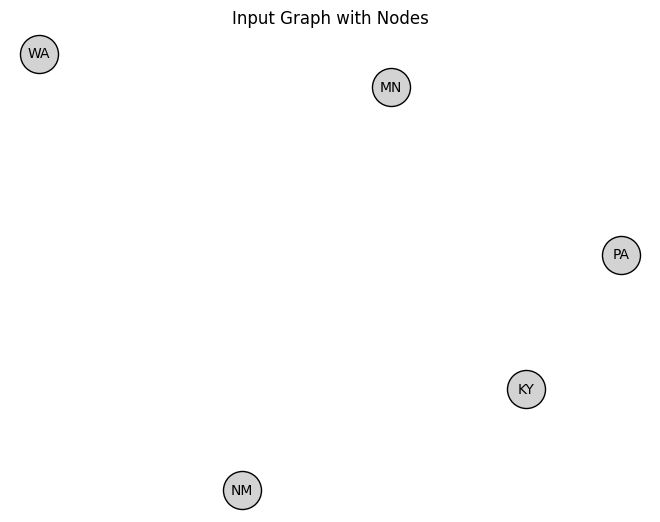

,usa_state_code,x,y
17,KY,0.837441,0.230743
38,PA,0.999873,0.538893
48,WA,-0.000184,0.999774
32,NM,0.348732,-0.000011
23,MN,0.604846,0.923149


In [126]:
# Build a simple graph for the input
G = nx.Graph()

# Use state code as nodes
for id, row in data_custom.iterrows():
    G.add_node(row['usa_state_code'], pos=(row['x'], row['y']))

info = data_custom[['usa_state_code', 'x', 'y']]
pos = nx.get_node_attributes(G, 'pos')

nx.draw(G, pos, with_labels=True, node_color='lightgrey', node_size=750, font_size=10, font_color='black', edgecolors='black')
plt.title('Input Graph with Nodes')
plt.show()

display(info)

Calculate the distance between nodes using the "Distance Formula":

***d = sqrt((x2 - x1)^2 + (y2 - y1)^2)***

Note: The distance is inversed because farther distance has lower weights on the edges.

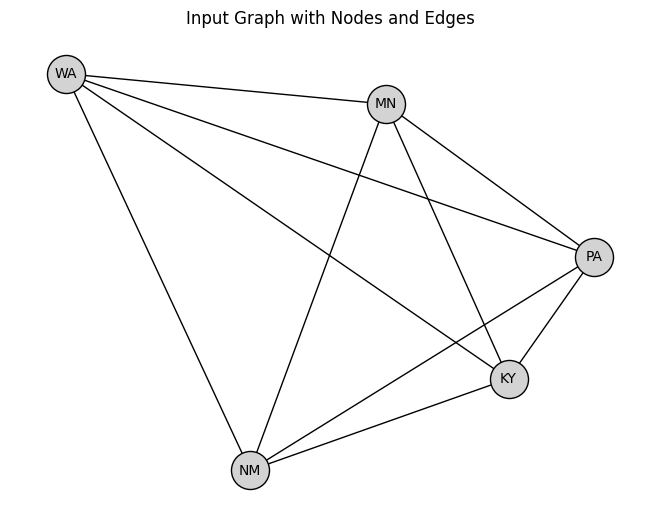

,usa_state_code,x,y
17,KY,0.837441,0.230743
38,PA,0.999873,0.538893
48,WA,-0.000184,0.999774
32,NM,0.348732,-0.000011
23,MN,0.604846,0.923149


In [142]:
# Add edges based on the distance (inverse) between nodes
for i in range(len(info)):
  for j in range(i+1, len(info)):
    x1 = info.iloc[i]['x']
    x2 = info.iloc[j]['x']
    y1 = info.iloc[i]['y']
    y2 = info.iloc[j]['y']

    # Distance between nodes
    d = np.sqrt((x2-x1)**2 + (y2-y1)**2)

    # Weight of edges (inverse of distance = the farther the node, the lower the weight)
    w = 1/d if d>0 else 0

    G.add_edge(info.iloc[i]['usa_state_code'], info.iloc[j]['usa_state_code'], weight=w)

pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_color='lightgrey', node_size=750, font_size=10, font_color='black', edgecolors='black')
plt.title('Input Graph with Nodes and Edges')
plt.show()

display(info)

Adding weights directly to the graph's edges. This is different than the weights/bias parameters in neural networks.

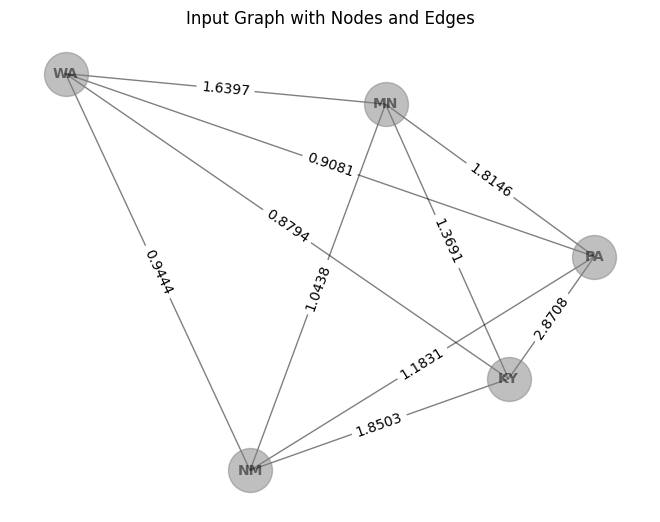

{('KY', 'PA'): np.float64(2.8707567908470497),
 ('KY', 'WA'): np.float64(0.8794203080677329),
 ('KY', 'NM'): np.float64(1.8503157168565179),
 ('KY', 'MN'): np.float64(1.369057084749281),
 ('PA', 'WA'): np.float64(0.9081437265041548),
 ('PA', 'NM'): np.float64(1.1831186155343179),
 ('PA', 'MN'): np.float64(1.8145886137864529),
 ('WA', 'NM'): np.float64(0.944357757315204),
 ('WA', 'MN'): np.float64(1.6397130314271946),
 ('NM', 'MN'): np.float64(1.0438093270319244)}

In [143]:
from numpy.random.mtrand import f
pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_color='grey', node_size=1000, font_size=10, font_color='black', font_weight='bold', edge_color='black', alpha=0.5)

# Add weights to the graph's edges
edge_attributes = nx.get_edge_attributes(G, 'weight')

# Add weights with 4 decimal places (Gemini AI)
edge_labels_attributes = {k: f'{v:.4f}' for k, v in edge_attributes.items()}

# Draw edges
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_attributes, font_color='black', font_size=10)
plt.title('Input Graph with Nodes and Edges')
plt.show()

# Show the edge weights
display(nx.get_edge_attributes(G, 'weight'))


Add random noise and remove 2-3 random edges to make it suitable for the input graph.

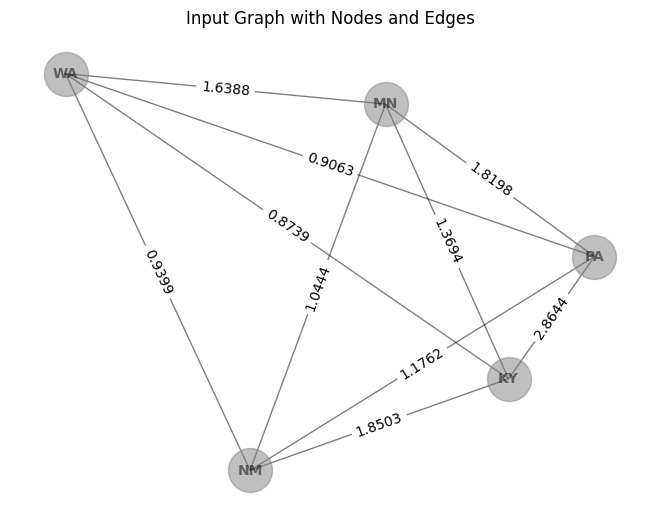

{('KY', 'PA'): np.float64(2.8643601563930465),
 ('KY', 'WA'): np.float64(0.8739390290943705),
 ('KY', 'NM'): np.float64(1.8503068530122795),
 ('KY', 'MN'): np.float64(1.3693835688126155),
 ('PA', 'WA'): np.float64(0.9062590347442202),
 ('PA', 'NM'): np.float64(1.1761705324276288),
 ('PA', 'MN'): np.float64(1.819816083343028),
 ('WA', 'NM'): np.float64(0.9399309181943741),
 ('WA', 'MN'): np.float64(1.638839535570523),
 ('NM', 'MN'): np.float64(1.0444226240151109)}

In [144]:
# Variables
random_noise = 0.003
edges_to_remove = 3
edge_threshold = 0.75
i = 0

# Remove "random_edges_to_remove" number of edges from the graph
while i < edges_to_remove:
  # Collect edges to remove
  collect_edges = []
  for u, v, data in G.edges(data=True):
    # Remove only edges that are less than "edge_threshold" because distance is too far
    if data['weight'] < edge_threshold:
      collect_edges.append((u, v))
    # If not removed, add random noise
    else:
      data['weight'] = data['weight'] + np.random.normal(0, random_noise)
    i+=1
  G.remove_edges_from(collect_edges)


# Draw graph again

pos = nx.get_node_attributes(G, 'pos')
nx.draw(G, pos, with_labels=True, node_color='grey', node_size=1000, font_size=10, font_color='black', font_weight='bold', edge_color='black', alpha=0.5)

# Add weights to the graph's edges
edge_attributes = nx.get_edge_attributes(G, 'weight')
edge_labels_attributes = {k: f'{v:.4f}' for k, v in edge_attributes.items()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_attributes, font_color='black', font_size=10)

plt.title('Input Graph with Nodes and Edges')
plt.show()

# Show the edge weights
display(nx.get_edge_attributes(G, 'weight'))



Find two random rows for source and destination for the input. If 0, retry the code until both are not null.

In [146]:
# Pick 2 random nodes

# Input Source
source = np.random.randint(0, len(data_custom))
# Input Destination
dest = np.random.randint(0, len(data_custom))

display(source, dest)

source_node = data_custom.iloc[source]
dest_node = data_custom.iloc[dest]

display(source_node, dest_node)

4

1

,23
usa_state_code,MN
x,0.604846
y,0.923149


,38
usa_state_code,PA
x,0.999873
y,0.538893


This data needs to be in tensor format in order to be used as data in the GNN/GCN model.

In [147]:
# Convert graph to tensor data
nodes = list(G.nodes)
edges = list(G.edges)

nodes_map = {node: i for i, node in enumerate(data_custom['usa_state_code'])}

tensor_map = []
for node in nodes:
  if node in nodes_map:
    node_tmp = nodes_map[node]
    tensor_map.append(data_custom.iloc[node_tmp][['x','y']].values)
  tensor_map.append([0.0, 0.0])

x = torch.tensor(tensor_map, dtype=torch.float)

source_tmp = [{name: i for i, name in enumerate(nodes)}[u] for u, v in edges]
dest_tmp = [{name: i for i, name in enumerate(nodes)}[v] for u, v in edges]

edge_index = torch.tensor([source_tmp, dest_tmp], dtype=torch.long)

# min, number of classification, size of layers, type)
y = torch.randint(0, 10, [2,4], dtype=torch.long)

# Create the data for the model
data = Data(x=x, edge_index=edge_index, y=y)

display(data)
display(data.num_nodes)
display(data.num_edges)

Data(x=[10, 2], edge_index=[2, 10], y=[2, 4])

10

10

In [148]:
# Parameters for Simple Phase
num_node_features = 2 # for x and y
input_size = 2
hidden_layer_size = 4
output_size = 2
num_hidden_layers = 2

In [149]:
# Create a GNN model for Simple Phase
class GNN(torch.nn.Module):
  def __init__(self, input_size, hidden_layer_size, output_size):
    super(GNN, self).__init__()
    self.conv1 = GCNConv(input_size, hidden_layer_size)
    self.conv2 = GCNConv(hidden_layer_size, output_size)

  # Define forward pass
  def forward(self, data):
    x, edge_index = data.x, data.edge_index
    x = self.conv1(x, edge_index)
    # ReLU activation function
    x = nf.relu(x)
    # Another hidden layer (convolutional layer)
    x = self.conv2(x, edge_index)
    # SoftMax to calculate probabilities on columns
    return nf.log_softmax(x, dim=1)

# Initialize model
model = GNN(input_size, hidden_layer_size, output_size)

# Optimizer and Backpropagation
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
model.train()
output = model(data)
mse_loss = MSELoss()
loss = mse_loss(output, data.x)
loss.backward()
optimizer.step()
print("This is the loss:")
display(loss.item())
print("")

# Display model
print("This is the model information:")
display(model)

This is the loss:


1.084699034690857


This is the model information:


GNN(
  (conv1): GCNConv(2, 4)
  (conv2): GCNConv(4, 2)
)

In [150]:
# Create a GCN model for Simple Phase
class GCN(torch.nn.Module):
  def __init__(self, num_node_features, hidden_layer_size):
    super(GCN, self).__init__()
    self.conv1 = GCNConv(num_node_features, hidden_layer_size)
    self.conv2 = GCNConv(hidden_layer_size, output_size)

  # Define forward pass
  def forward(self, data):
    x, edge_index = data.x, data.edge_index
    x = self.conv1(x, edge_index)
    # ReLU activation function
    x = nf.relu(x)
    # Another hidden layer (convolutional layer)
    x = self.conv2(x, edge_index)
    # SoftMax to calculate probabilities on columns
    return nf.log_softmax(x, dim=1)

# Initialize model
model = GCN(num_node_features, hidden_layer_size)

# Optimizer and Backpropagation
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
model.train()
output = model(data)
mse_loss = MSELoss()
loss = mse_loss(output, data.x)
loss.backward()
optimizer.step()
print("This is the loss:")
display(loss.item())
print("")

# Display model
print("This is the model information:")
display(model)

This is the loss:


1.079464316368103


This is the model information:


GCN(
  (conv1): GCNConv(2, 4)
  (conv2): GCNConv(4, 2)
)

Now that the model is defined, the A* method can be used in the output layer to find the optimized path from source_node to dest_node in the graph.

In this case, the edges are used to define the shortest path to keep the variables for the project simple.

In [151]:
# Create a distance function to reduce repetitive code
def distance(source, dest):
  # Source and Destination nodes
  x1 = nx.get_node_attributes(G, 'pos')[source][0]
  x2 = nx.get_node_attributes(G, 'pos')[dest][0]
  y1 = nx.get_node_attributes(G, 'pos')[source][1]
  y2 = nx.get_node_attributes(G, 'pos')[dest][1]

  # Distance between nodes
  return np.sqrt((x2-x1)**2 + (y2-y1)**2)

# Example distance calculation
display(float(distance(source_node['usa_state_code'], dest_node['usa_state_code'])))

0.5510890966704167

In [152]:
# A* algorithm for shortest path calculation
def a_star_search(G, source, dest):
  start = [(0, source, [source])]

  shortest_path = {node: float('inf') for node in G.nodes()}
  shortest_path[source] = 0

  optimal_path = {node: float('inf') for node in G.nodes()}
  optimal_path[source] = distance(source, dest)

  while start:
    # Build optimal path using node by node and path by path in a heap
    tmp_optimal_path, tmp_node, tmp_path = heapq.heappop(start)

    # If the current node is the destination node
    if tmp_node == dest:
      return tmp_path

    for neighbour in G.neighbors(tmp_node):
      x1 = nx.get_node_attributes(G, 'pos')[tmp_node][0]
      x2 = nx.get_node_attributes(G, 'pos')[neighbour][0]
      y1 = nx.get_node_attributes(G, 'pos')[tmp_node][1]
      y2 = nx.get_node_attributes(G, 'pos')[neighbour][1]

      # Distance between nodes
      d = distance(tmp_node, neighbour)

      # Calculate current shortest path and current optimal path
      if shortest_path[neighbour] > shortest_path[tmp_node] + d:
        # Current node and distance to neighbour
        shortest_path[neighbour] = shortest_path[tmp_node] + d
        # Neighbour and distance to destination
        optimal_path[neighbour] = shortest_path[neighbour] + distance(neighbour, dest)
        heapq.heappush(start, (optimal_path[neighbour], neighbour, tmp_path + [neighbour]))

  return "No Path Found."

In [153]:
# Find shortest path of the current graph
graph_shortest_path = a_star_search(G, source_node['usa_state_code'], dest_node['usa_state_code'])
display(graph_shortest_path)

['MN', 'PA']

In [154]:
# Find the total distance of this shortest path
if graph_shortest_path != 'No Path Found.':
  total_distance = 0
  for i in range(len(graph_shortest_path)-1):
    total_distance += distance(graph_shortest_path[i], graph_shortest_path[i+1])

  display(float(total_distance))

0.5510890966704167

The graph code above is used again to show the shortest path in different colours.

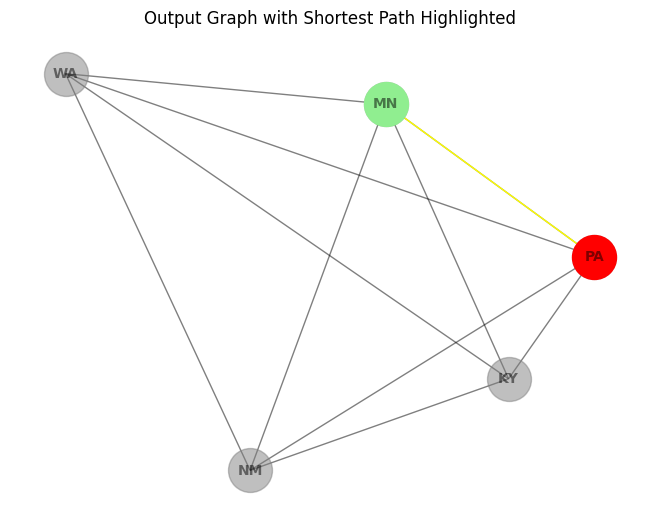

In [155]:
# Show the shortest path in the current graph
nx.draw(G, pos, with_labels=True, node_color='grey', node_size=1000, font_size=10, font_weight='bold', edge_color='black', alpha=0.5)

# Change colour of the shortest path
path_list = list(zip(graph_shortest_path, graph_shortest_path[1:]))
nx.draw_networkx_edges(G, pos, edgelist=path_list, edge_color='yellow')

# Change colour of start node
nx.draw_networkx_nodes(G, pos, nodelist=[graph_shortest_path[0]], node_color='lightgreen', node_size=1000)

# Change colour of start node
nx.draw_networkx_nodes(G, pos, nodelist=[graph_shortest_path[1]], node_color='red', node_size=1000)

plt.title('Output Graph with Shortest Path Highlighted')
plt.show()

The pyTorch library provides the function to get probabilities as the output.

In [156]:
# Get output probabilities
model.eval()
with torch.no_grad():
  output = model(data)
  probabilities = torch.exp(output)

display(probabilities[source].numpy(), probabilities[dest].numpy())

array([0.49313125, 0.5068688 ], dtype=float32)

array([0.49940524, 0.50059474], dtype=float32)

In [157]:
# Parameters for Medium Phase
input_size = 2
hidden_layer_size = 8
output_size = 2
num_hidden_layers = 3

# Parameters for Complex Phase
input_size = 2
hidden_layer_size = 64
output_size = 2
num_hidden_layers = 5